In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [188]:
datos = pd.read_csv("datos\\Datos SINAICA.csv", encoding='latin1', engine='python')
datos.head()

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_
3,PM10,01/08/2025,2:00 - 3:00,-7,µg/m_
4,PM10,01/08/2025,3:00 - 4:00,20,µg/m_


Observamos como es que está la serie de las concentraciones horarias

Text(0.5, 1.0, 'Concentración datos crudos')

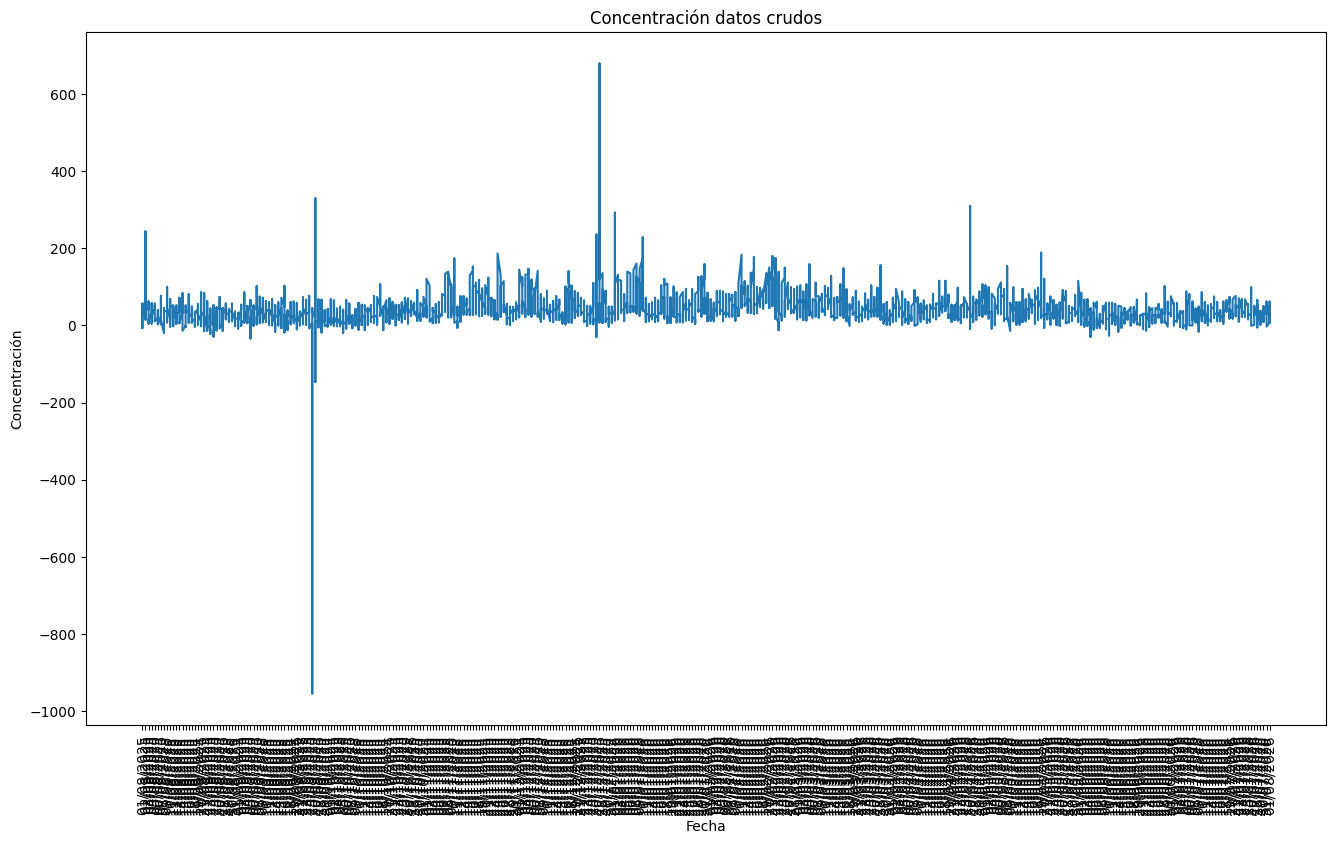

In [189]:
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['Concentraciones horarias'])
plt.ylabel('Concentración')
plt.xticks(rotation=90)
plt.xlabel('Fecha')
plt.title('Concentración datos crudos')

quitamos valores negativos

Text(0.5, 1.0, 'Concentración datos limpios')

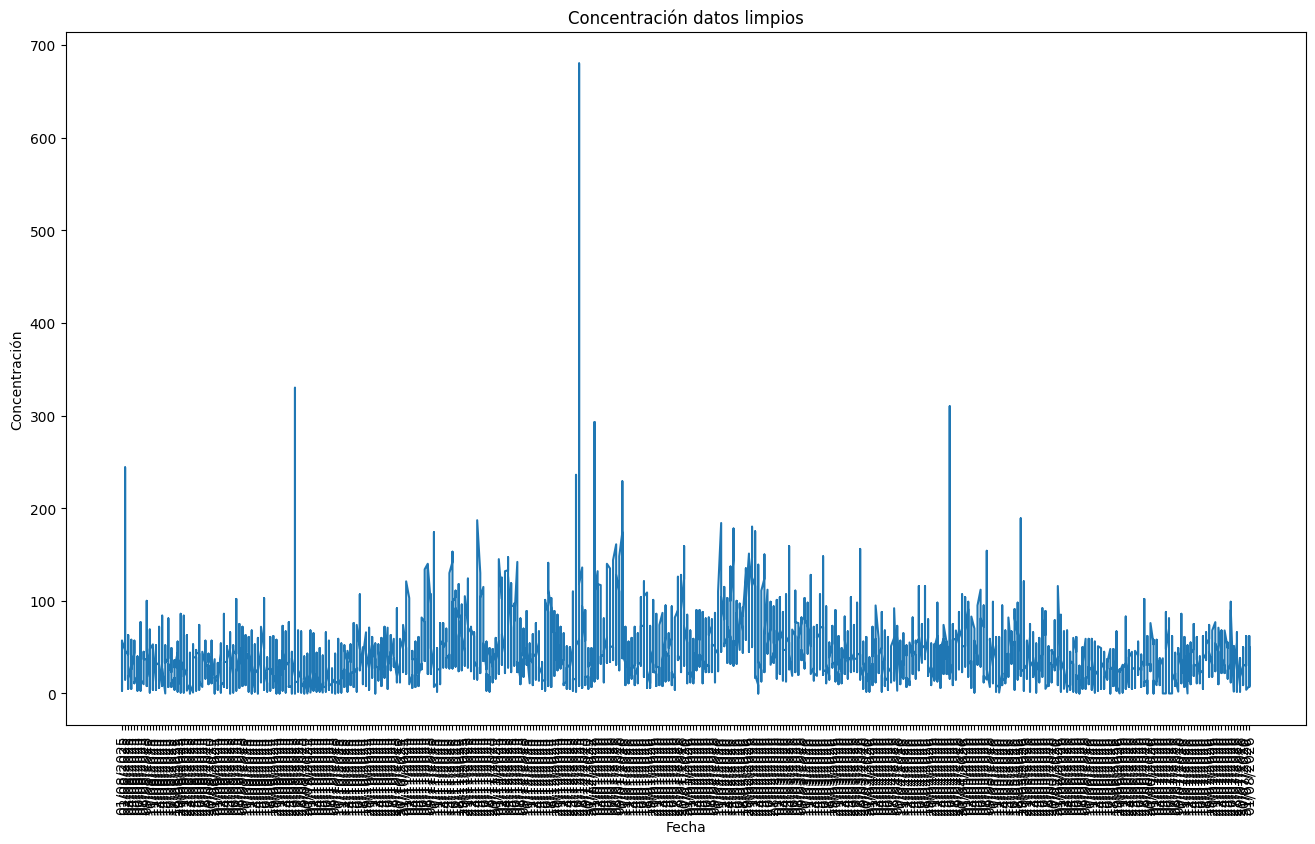

In [190]:
datos = datos[datos['Concentraciones horarias'] >= 0] 
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['Concentraciones horarias'])
plt.ylabel('Concentración')
plt.xticks(rotation=90)
plt.xlabel('Fecha')
plt.title('Concentración datos limpios')

# Smoothing by bin

### Mean

In [191]:
mean_by_day = datos.groupby('Fecha', as_index=False)['Concentraciones horarias'].mean()
mean_by_day = mean_by_day.rename(columns={'Concentraciones horarias': 'Smoothing_mean_day'})
mean_by_day.head(10)

,Fecha,Smoothing_mean_day
0,01/01/2026,103.083333
1,01/02/2026,27.416667
2,01/03/2026,50.083333
3,01/04/2026,32.208333
4,01/05/2026,60.458333
5,01/06/2026,29.083333
6,01/07/2026,33.291667
7,01/08/2025,26.739130
8,01/08/2026,28.416667
9,01/09/2025,15.608696


In [192]:
datos = pd.merge(datos, mean_by_day, on='Fecha', how='left')
datos

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Smoothing_mean_day
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,26.739130
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,26.739130
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,26.739130
3,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,26.739130
4,PM10,01/08/2025,4:00 - 5:00,19,µg/m_,26.739130
...,...,...,...,...,...,...
8623,PM10,01/08/2026,18:00 - 19:00,7,µg/m_,28.416667
8624,PM10,01/08/2026,19:00 - 20:00,36,µg/m_,28.416667
8625,PM10,01/08/2026,20:00 - 21:00,28,µg/m_,28.416667
8626,PM10,01/08/2026,21:00 - 22:00,20,µg/m_,28.416667


Text(0.5, 1.0, 'Smoothing por bin_mean por dia')

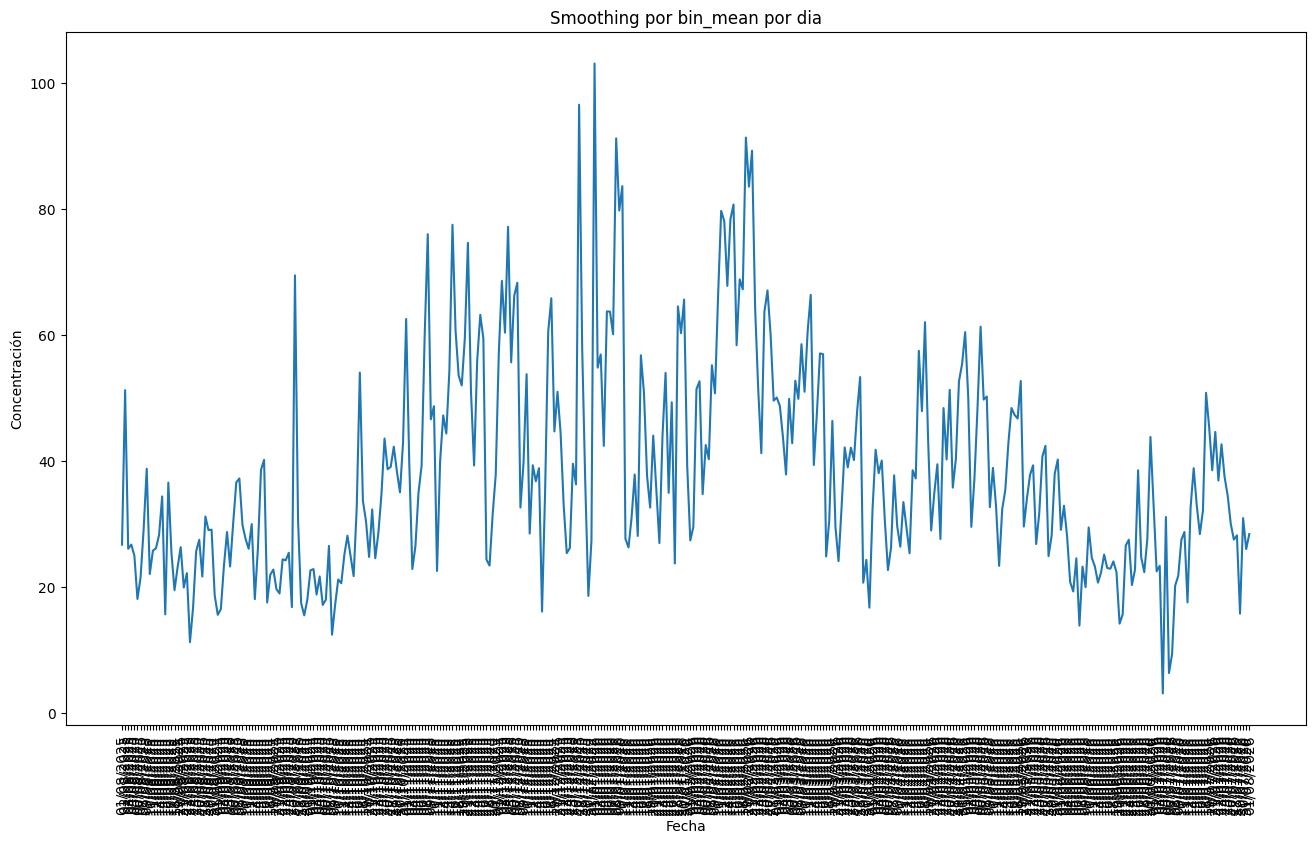

In [193]:
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['Smoothing_mean_day'])
plt.ylabel('Concentración')
plt.xticks(rotation=90)
plt.xlabel('Fecha')
plt.title('Smoothing por bin_mean por dia')

### Median

In [194]:
median_by_day = datos.groupby('Fecha', as_index=False)['Concentraciones horarias'].median()
median_by_day = median_by_day.rename(columns={'Concentraciones horarias': 'Smoothing_median_day'})
median_by_day.head()

,Fecha,Smoothing_median_day
0,01/01/2026,73.0
1,01/02/2026,25.5
2,01/03/2026,44.0
3,01/04/2026,30.0
4,01/05/2026,57.5


In [195]:
datos = pd.merge(datos, median_by_day, on='Fecha', how='left')
datos

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Smoothing_mean_day,Smoothing_median_day
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,26.739130,27.0
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,26.739130,27.0
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,26.739130,27.0
3,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,26.739130,27.0
4,PM10,01/08/2025,4:00 - 5:00,19,µg/m_,26.739130,27.0
...,...,...,...,...,...,...,...
8623,PM10,01/08/2026,18:00 - 19:00,7,µg/m_,28.416667,27.5
8624,PM10,01/08/2026,19:00 - 20:00,36,µg/m_,28.416667,27.5
8625,PM10,01/08/2026,20:00 - 21:00,28,µg/m_,28.416667,27.5
8626,PM10,01/08/2026,21:00 - 22:00,20,µg/m_,28.416667,27.5


Text(0.5, 1.0, 'Smoothing por bin_median por dia')

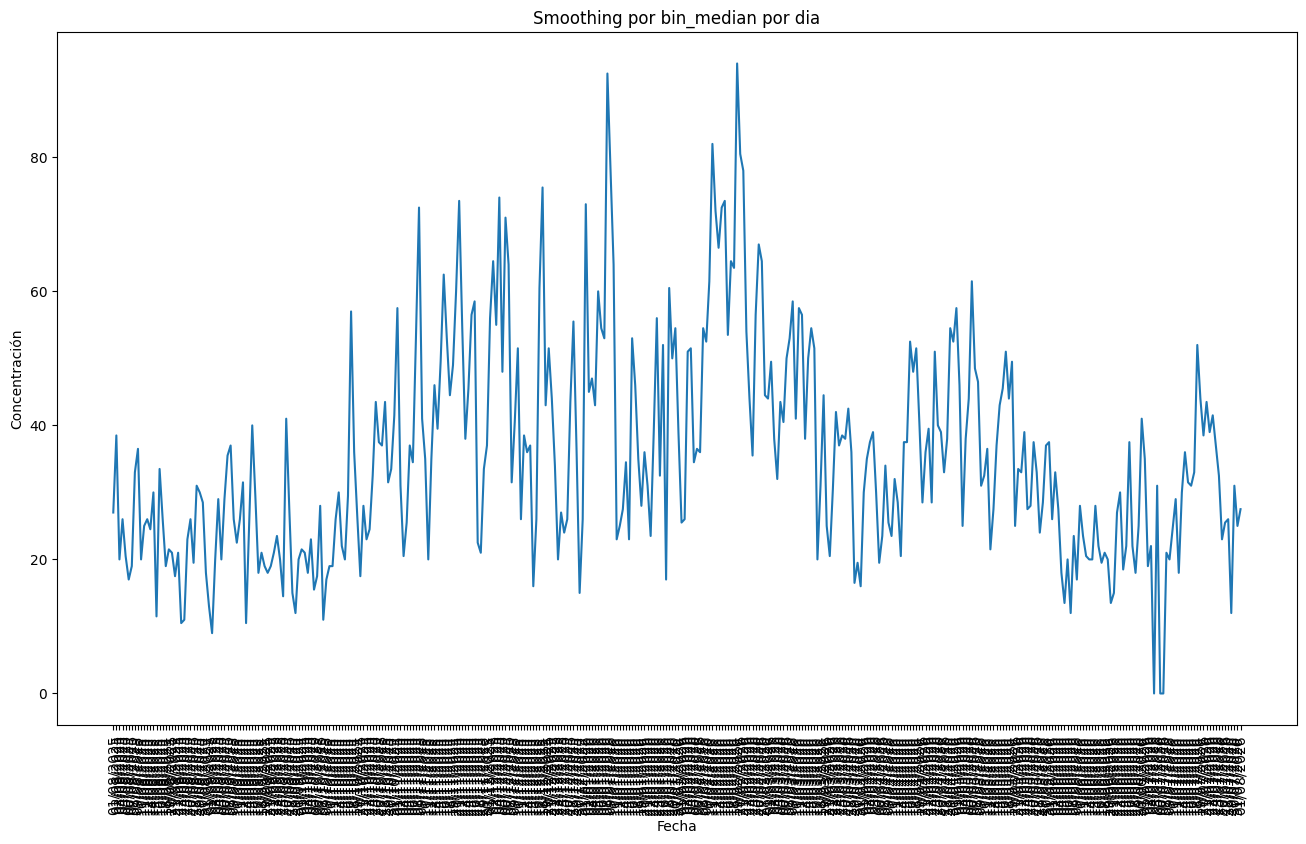

In [196]:
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['Smoothing_median_day'])
plt.ylabel('Concentración')
plt.xticks(rotation=90)
plt.xlabel('Fecha')
plt.title('Smoothing por bin_median por dia')

### boundaries

In [197]:
boundaries_by_day = datos.groupby('Fecha', as_index=False).agg(
    lim_min=('Concentraciones horarias', 'min'),
    lim_max=('Concentraciones horarias', 'max')
)
boundaries_by_day.head()

,Fecha,lim_min,lim_max
0,01/01/2026,13,293
1,01/02/2026,12,68
2,01/03/2026,16,101
3,01/04/2026,9,72
4,01/05/2026,29,104


In [198]:
datos = pd.merge(datos, boundaries_by_day, on='Fecha', how='left')
datos

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Smoothing_mean_day,Smoothing_median_day,lim_min,lim_max
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,26.739130,27.0,3,57
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,26.739130,27.0,3,57
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,26.739130,27.0,3,57
3,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,26.739130,27.0,3,57
4,PM10,01/08/2025,4:00 - 5:00,19,µg/m_,26.739130,27.0,3,57
...,...,...,...,...,...,...,...,...,...
8623,PM10,01/08/2026,18:00 - 19:00,7,µg/m_,28.416667,27.5,7,62
8624,PM10,01/08/2026,19:00 - 20:00,36,µg/m_,28.416667,27.5,7,62
8625,PM10,01/08/2026,20:00 - 21:00,28,µg/m_,28.416667,27.5,7,62
8626,PM10,01/08/2026,21:00 - 22:00,20,µg/m_,28.416667,27.5,7,62


In [199]:
dist_min = abs(datos['Concentraciones horarias'] - datos['lim_min'])
dist_max = abs(datos['lim_max'] - datos['Concentraciones horarias'])
datos['Smoothing_boundaries_day'] = np.where(dist_min < dist_max, datos['lim_min'], datos['lim_max'])
datos

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Smoothing_mean_day,Smoothing_median_day,lim_min,lim_max,Smoothing_boundaries_day
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,26.739130,27.0,3,57,3
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,26.739130,27.0,3,57,57
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,26.739130,27.0,3,57,3
3,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,26.739130,27.0,3,57,3
4,PM10,01/08/2025,4:00 - 5:00,19,µg/m_,26.739130,27.0,3,57,3
...,...,...,...,...,...,...,...,...,...,...
8623,PM10,01/08/2026,18:00 - 19:00,7,µg/m_,28.416667,27.5,7,62,7
8624,PM10,01/08/2026,19:00 - 20:00,36,µg/m_,28.416667,27.5,7,62,62
8625,PM10,01/08/2026,20:00 - 21:00,28,µg/m_,28.416667,27.5,7,62,7
8626,PM10,01/08/2026,21:00 - 22:00,20,µg/m_,28.416667,27.5,7,62,7


Text(0.5, 1.0, 'Smoothing por bin_boundaries por dia')

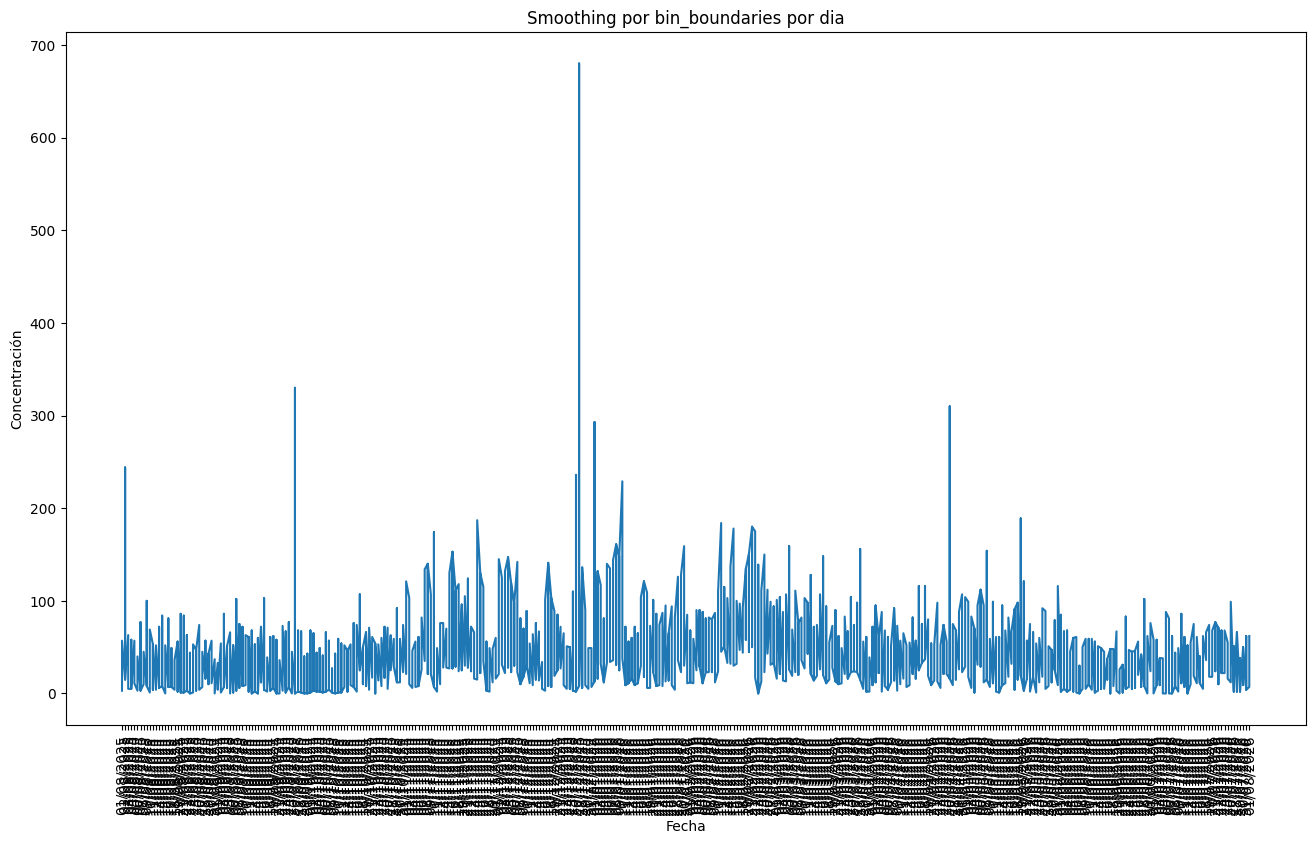

In [200]:
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['Smoothing_boundaries_day'])
plt.ylabel('Concentración')
plt.xticks(rotation=90)
plt.xlabel('Fecha')
plt.title('Smoothing por bin_boundaries por dia')

# Smoothing by moving average

In [201]:
datos['Moving_average'] = datos['Concentraciones horarias'].rolling(window=5,center=True).mean()
datos.head()

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Smoothing_mean_day,Smoothing_median_day,lim_min,lim_max,Smoothing_boundaries_day,Moving_average
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,26.73913,27.0,3,57,3,NaN
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,26.73913,27.0,3,57,57,NaN
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,26.73913,27.0,3,57,3,21.0
3,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,26.73913,27.0,3,57,3,16.8
4,PM10,01/08/2025,4:00 - 5:00,19,µg/m_,26.73913,27.0,3,57,3,11.8


Text(0.5, 1.0, 'Smoothing por promedio movil')

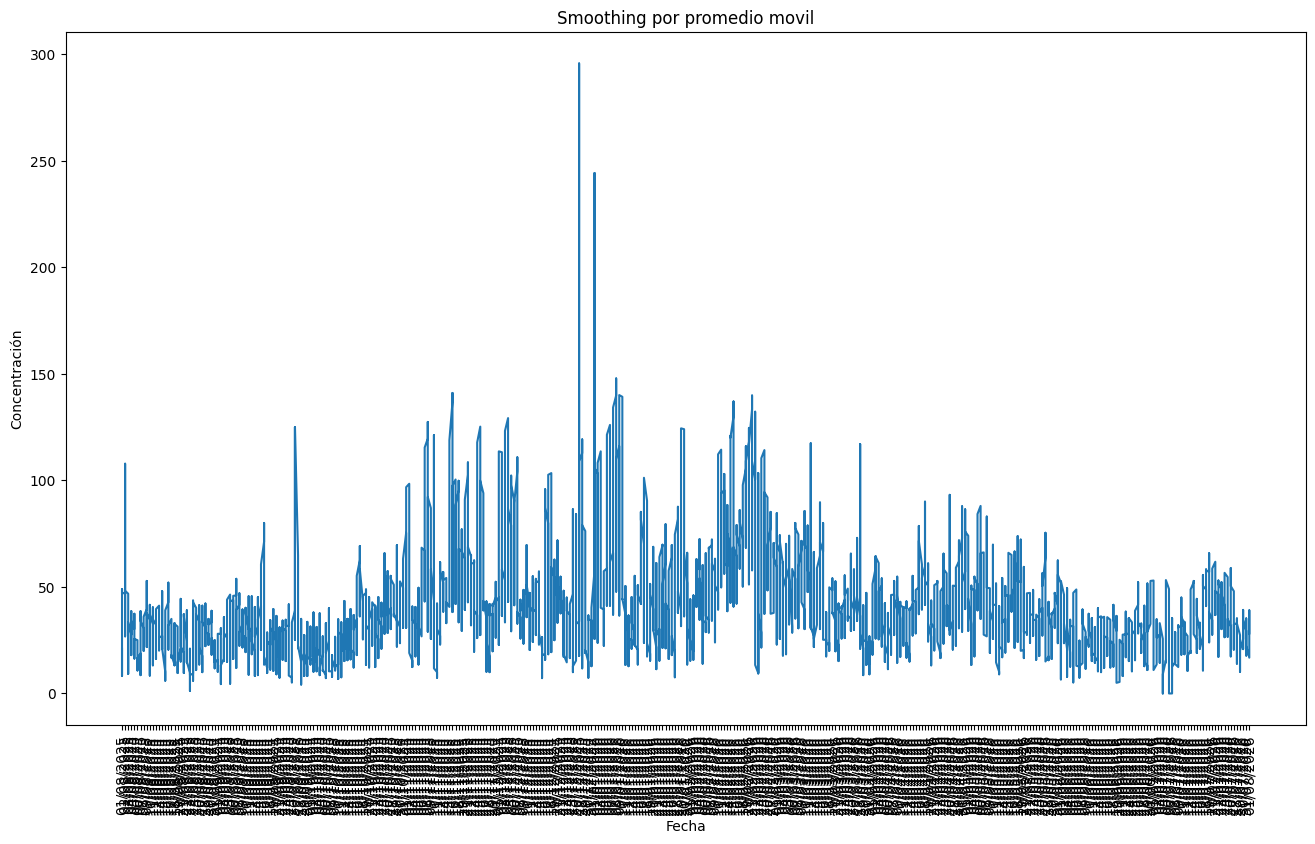

In [202]:
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['Moving_average'])
plt.ylabel('Concentración')
plt.xticks(rotation=90)
plt.xlabel('Fecha')
plt.title('Smoothing por promedio movil')

# Smoothing by average (weigthed)

In [203]:
weights = {'hora':list(range(0,24)),
                'peso':[1, 1, 1, 1, 1, 1, 2, 2, 5, 3, 1, 1,
                        1, 2, 4, 3, 2, 2, 5, 3, 2, 2, 1, 1]}

weights = pd.DataFrame(weights)
weights['peso'].sum()
# weights

np.int64(48)

In [204]:
datos['hora_entero'] = datos['Hora'].str.split(':').str[0].astype(int)
datos = pd.merge( datos, weights, left_on='hora_entero', right_on='hora', how='left')
datos = datos.drop(columns=['hora_entero'])
datos.head()

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Smoothing_mean_day,Smoothing_median_day,lim_min,lim_max,Smoothing_boundaries_day,Moving_average,hora,peso
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,26.73913,27.0,3,57,3,NaN,23,1
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,26.73913,27.0,3,57,57,NaN,0,1
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,26.73913,27.0,3,57,3,21.0,1,1
3,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,26.73913,27.0,3,57,3,16.8,3,1
4,PM10,01/08/2025,4:00 - 5:00,19,µg/m_,26.73913,27.0,3,57,3,11.8,4,1


In [205]:
datos['hora_x_peso'] = datos['Concentraciones horarias'] * datos['peso']
productos = datos['hora_x_peso'].rolling(window=5, center=True).sum()
totales = datos['peso'].rolling(window=5, center=True).sum()
datos['Smoothing_weight'] = productos/totales
datos = datos.drop(columns=['hora_x_peso'])
datos.head()

,Parametro,Fecha,Hora,Concentraciones horarias,Unidad,Smoothing_mean_day,Smoothing_median_day,lim_min,lim_max,Smoothing_boundaries_day,Moving_average,hora,peso,Smoothing_weight
0,PM10,01/08/2025,23:00 - 0:00,27,µg/m_,26.73913,27.0,3,57,3,NaN,23,1,NaN
1,PM10,01/08/2025,0:00 - 1:00,34,µg/m_,26.73913,27.0,3,57,57,NaN,0,1,NaN
2,PM10,01/08/2025,1:00 - 2:00,5,µg/m_,26.73913,27.0,3,57,3,21.0,1,1,21.000000
3,PM10,01/08/2025,3:00 - 4:00,20,µg/m_,26.73913,27.0,3,57,3,16.8,3,1,16.800000
4,PM10,01/08/2025,4:00 - 5:00,19,µg/m_,26.73913,27.0,3,57,3,11.8,4,1,11.333333


Text(0.5, 1.0, 'Smoothing por promedio ponderado movil')

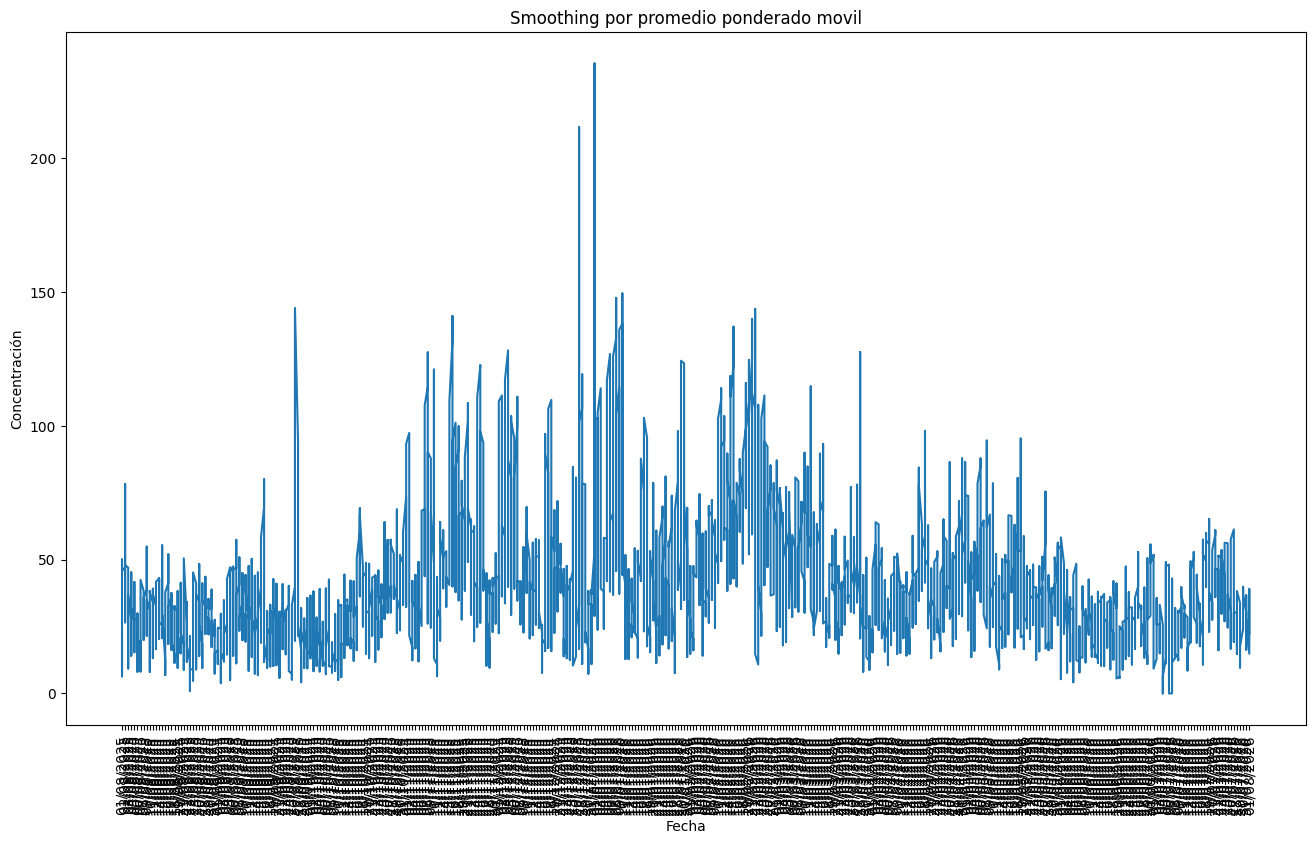

In [206]:
plt.figure(figsize=(16,9))
plt.plot(datos['Fecha'], datos['Smoothing_weight'])
plt.ylabel('Concentración')
plt.xticks(rotation=90)
plt.xlabel('Fecha')
plt.title('Smoothing por promedio ponderado movil')

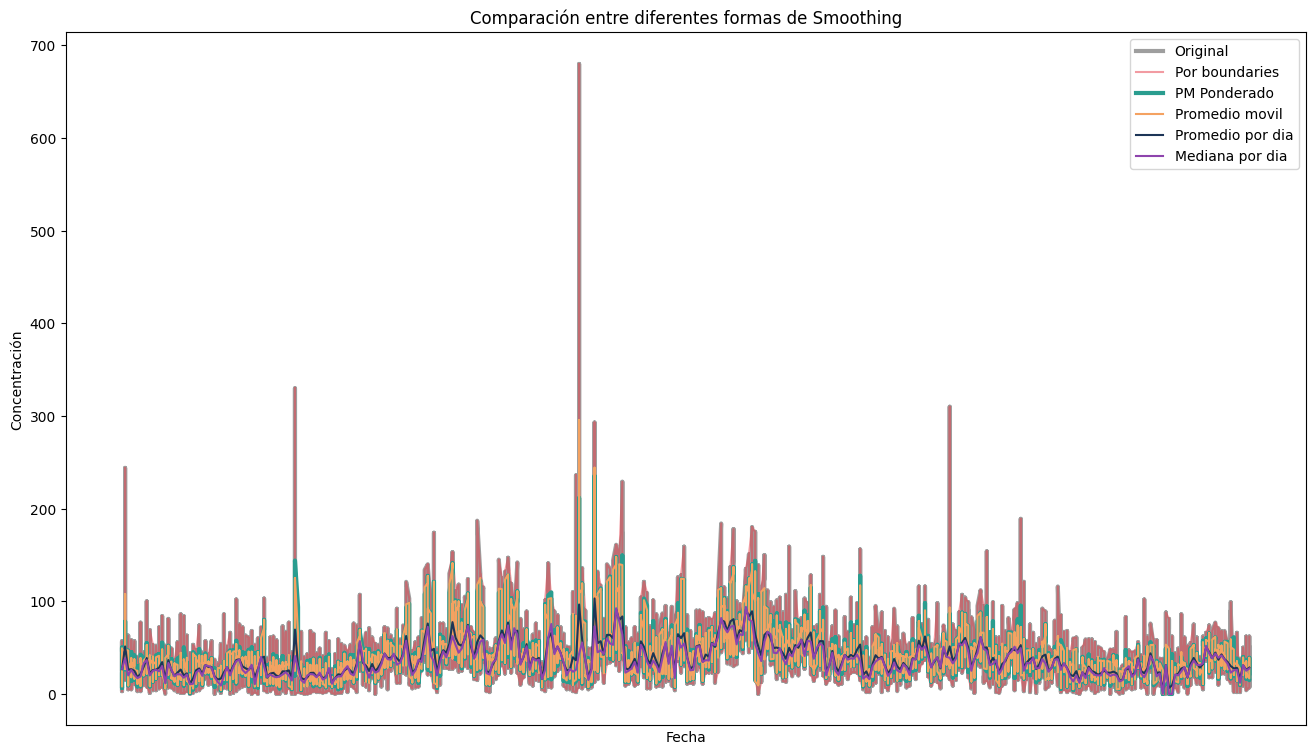

In [207]:
plt.figure(figsize=(16,9))
# plt.plot(datos['Fecha'], datos['Concentraciones horarias'], color='#A71B4B', label='Original')
# plt.plot(datos['Fecha'], datos['Smoothing_boundaries_day'], color='#4461A8', label='Por boundaries')
# plt.plot(datos['Fecha'], datos['Smoothing_weight'], color='#EE850E', label='Ponderado')
# plt.plot(datos['Fecha'], datos['Moving_average'], color='#0096B5', label='Promedio movil')
# plt.plot(datos['Fecha'], datos['Smoothing_mean_day'], color='#FBD678', label='Promedio por dia')
# plt.plot(datos['Fecha'], datos['Smoothing_median_day'], color='#6BD7AF', label='Mediana por dia')
plt.plot(datos['Fecha'], datos['Concentraciones horarias'], color='#9E9E9E',linewidth=3, label='Original')
plt.plot(datos['Fecha'], datos['Smoothing_boundaries_day'], color='#E63946', alpha=0.5,label='Por boundaries')
plt.plot(datos['Fecha'], datos['Smoothing_weight'], color='#2A9D8F', linewidth=3, label='PM Ponderado')
plt.plot(datos['Fecha'], datos['Moving_average'], color='#F4A261', label='Promedio movil')
plt.plot(datos['Fecha'], datos['Smoothing_mean_day'], color='#1D3557', label='Promedio por dia')
plt.plot(datos['Fecha'], datos['Smoothing_median_day'], color='#8E44AD', label='Mediana por dia')
plt.ylabel('Concentración')
plt.xticks([])
plt.xlabel('Fecha')
plt.title('Comparación entre diferentes formas de Smoothing')
plt.legend()
